# MrSQM vs HYDRA — Reproducibility & Statistical Analysis

In [1]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings("ignore")

### Step up the environment and output directory for figures

In [2]:
OUTPUT_DIR = "figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [3]:
from mrsqm_vs_hyrda_utils import (
    load_data,
    compute_summary_stats,
    compute_average_ranks,
    run_wilcoxon_tests,
    plot_scatter_my_vs_reported,
    plot_diff_bars,
    _plot_critical_difference,
    plot_critical_difference,
    plot_accuracy_distributions,
    plot_win_counts,
    plot_combined_figure
)

In [4]:
print("\n" + "█"*60)
print("  MrSQM vs HYDRA  —  Full Reproducibility Analysis")
print("█"*60)

df = load_data()
print(f"\nLoaded {len(df)} datasets.")


████████████████████████████████████████████████████████████
  MrSQM vs HYDRA  —  Full Reproducibility Analysis
████████████████████████████████████████████████████████████
model                  hydra       mrsqm
total_time count  128.000000  128.000000
           mean     9.046189   22.163786
           std     36.821275   41.329212
           min      0.042668    0.163872
           25%      0.540127    1.997131
           50%      1.653679    5.973638
           75%      6.050677   21.930829
           max    409.911766  333.811691
accuracy   count  128.000000  128.000000
           mean     0.848360    0.846887
           std      0.149701    0.143185
           min      0.324367    0.366034
           25%      0.766558    0.769005
           50%      0.892356    0.889630
           75%      0.969003    0.962646
           max      1.000000    1.000000
          count      mean       std       min      25%       50%       75%  \
accuracy  112.0  0.873464  0.131359  0.329712  0.80

The dataframe compares the reported results vs the our reproduced scores.  
We also capture the differences in the results, the "winner" (the more accurate model, accuracy was used as the score to align with reported metric for each paper.)

In [5]:
df.head()

,dataset,mrsqm,hydra,mrsqm_reported,hydra_reported,mrsqm_diff,hydra_diff,my_winner,rep_winner,rank_agrees
0,ACSF1,0.930000,0.880000,0.890,0.806667,0.040000,0.073333,mrsqm,mrsqm,True
1,Adiac,0.818414,0.813299,0.811,0.815772,0.007414,-0.002473,mrsqm,hydra,False
2,ArrowHead,0.811429,0.811429,0.851,0.869714,-0.039571,-0.058285,tie,hydra,False
3,Beef,0.766667,0.833333,0.800,0.805556,-0.033333,0.027777,hydra,hydra,True
4,BeetleFly,0.950000,0.900000,0.950,0.951667,0.000000,-0.051667,mrsqm,hydra,False


In [6]:
summary_df = compute_summary_stats(df)


SUMMARY STATISTICS  (accuracy, N=112)
                   Mean    Std  Median    Min    Max
Model                                               
MrSQM (ours)     0.8556 0.1395  0.9080 0.3660 1.0000
HYDRA (ours)     0.8563 0.1488  0.9036 0.3244 1.0000
MrSQM (reported) 0.8524 0.1409  0.8915 0.3720 1.0000
HYDRA (reported) 0.8735 0.1314  0.9300 0.3297 1.0000

Win counts (head-to-head per dataset):
  Our results       mrsqm:  44  hydra:  52  tie:  16
  Reported          mrsqm:  41  hydra:  69  tie:   2

Ranking agreement (our results vs reported winner): 71/112 = 63.4%


In [7]:
# For the summary df we calculate the statics for both our results and the reported results, so we can compare them side by side.
# Surprisingly, our results are very close to the reported results, with a bigger gap between Hydra reported and our calculated results. 
# This could be due to differences in the evaluation setup, random seeds, or other factors.

In [8]:
# 2. Average ranks
rank_results = compute_average_ranks(df)


AVERAGE RANK  (lower = better, N=112)
  My results        MrSQM=1.5357  HYDRA=1.4643  => winner: HYDRA
  Reported          MrSQM=1.6250  HYDRA=1.3750  => winner: HYDRA


In [9]:
# 3. Wilcoxon tests
wilcoxon_df = run_wilcoxon_tests(df)


WILCOXON SIGNED-RANK TESTS

  (A) H2H — ours
    Is HYDRA significantly better than MrSQM in our single-run experiments?
    n= 96  W=2196.50  p=0.6308  n.s.  mean_diff=+0.0007

  (B) H2H — reported
    Is HYDRA significantly better than MrSQM in the reported results?
    n=110  W=1916.00  p=0.0007  ***  mean_diff=+0.0211

  (C) Repro — MrSQM
    Do our MrSQM results significantly differ from the reported figures?
    n=103  W=2578.00  p=0.7422  n.s.  mean_diff=+0.0033

  (D) Repro — HYDRA
    Do our HYDRA results significantly differ from the reported figures?
    n=107  W=2152.00  p=0.0220  *  mean_diff=-0.0171

  Significance codes: *** p<0.001  ** p<0.01  * p<0.05  n.s. p>=0.05


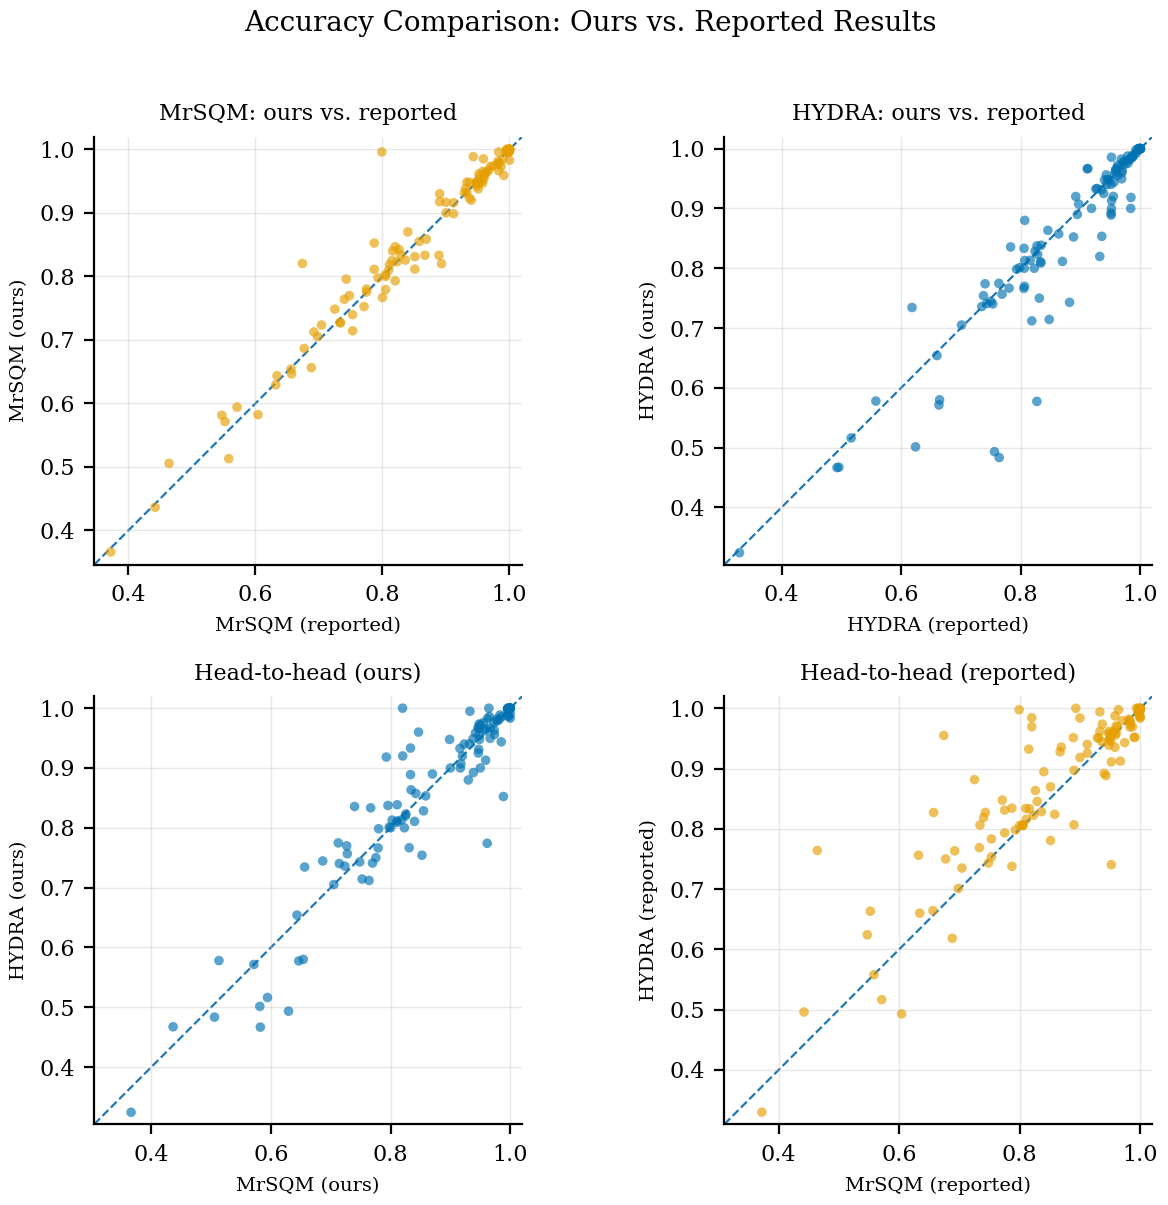


[plot_scatter_my_vs_reported] Saved -> figures/scatter_my_vs_reported.png


'figures/scatter_my_vs_reported.png'

In [10]:
plot_scatter_my_vs_reported(df)

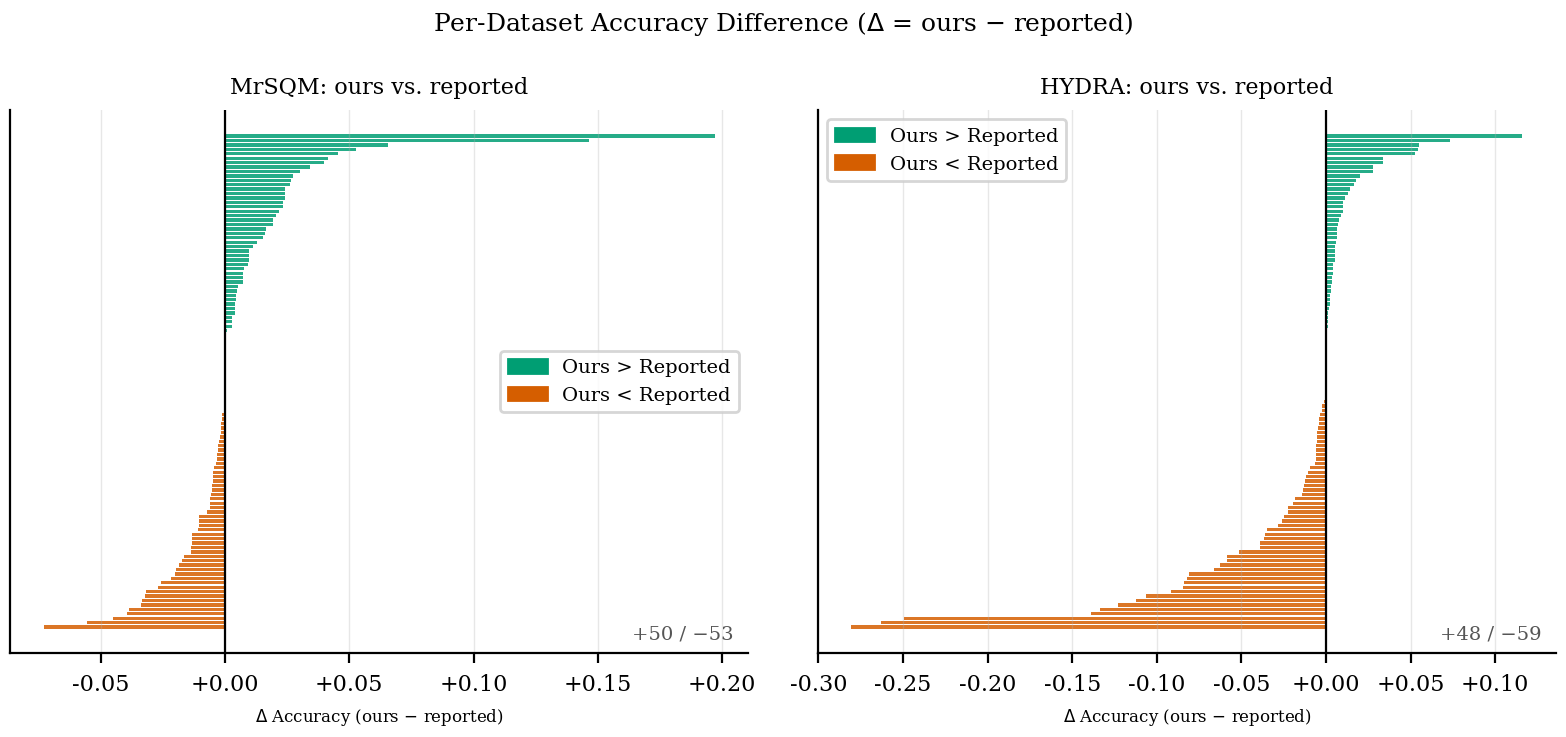

[plot_diff_bars] Saved -> figures/diff_bars.png


'figures/diff_bars.png'

In [11]:
plot_diff_bars(df)


AVERAGE RANK  (lower = better, N=112)
  My results        MrSQM=1.5357  HYDRA=1.4643  => winner: HYDRA
  Reported          MrSQM=1.6250  HYDRA=1.3750  => winner: HYDRA


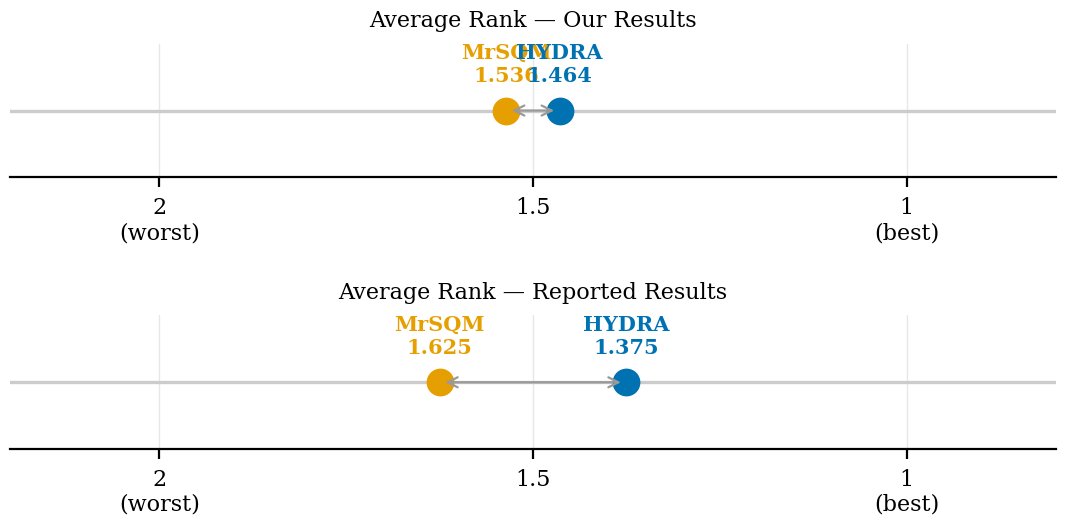

[plot_critical_difference] Saved -> figures/critical_difference.png


'figures/critical_difference.png'

In [12]:
plot_critical_difference(df)

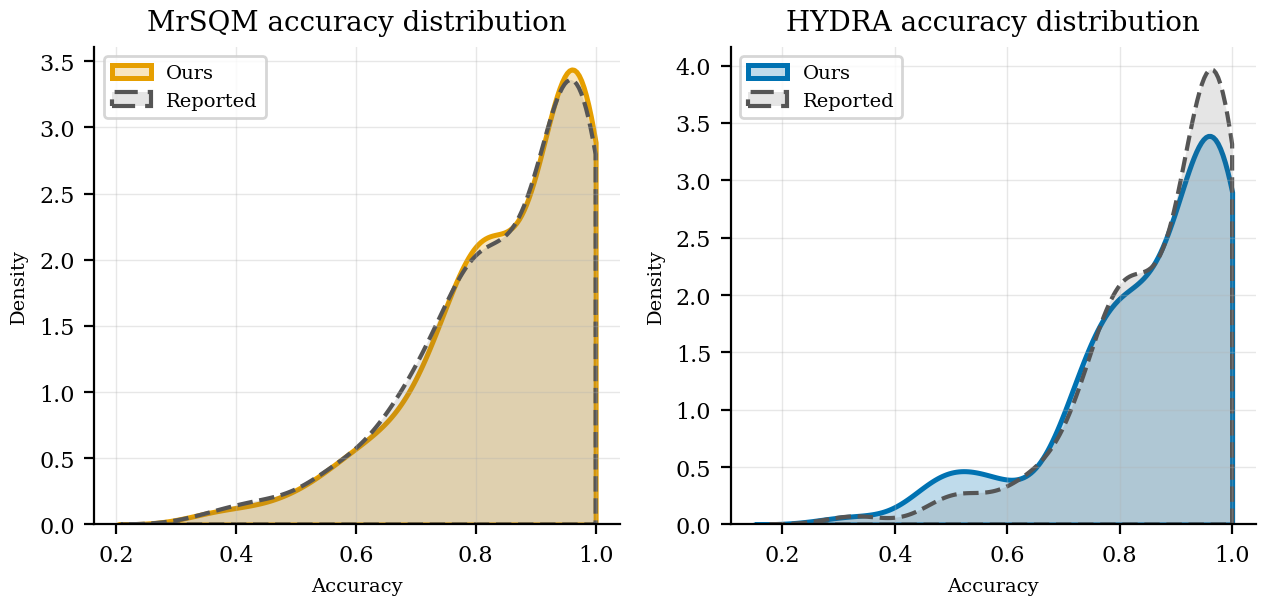

[plot_accuracy_distributions] Saved -> figures/accuracy_distributions.png


'figures/accuracy_distributions.png'

In [13]:
plot_accuracy_distributions(df)

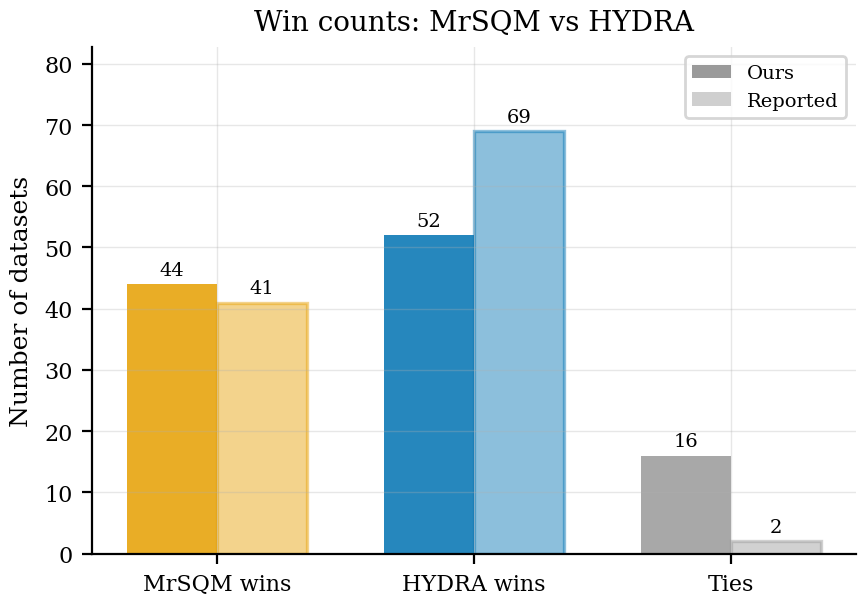

[plot_win_counts] Saved -> figures/win_counts.png


'figures/win_counts.png'

In [14]:
plot_win_counts(df)

In [15]:
x = np.array([1, 2, 3])

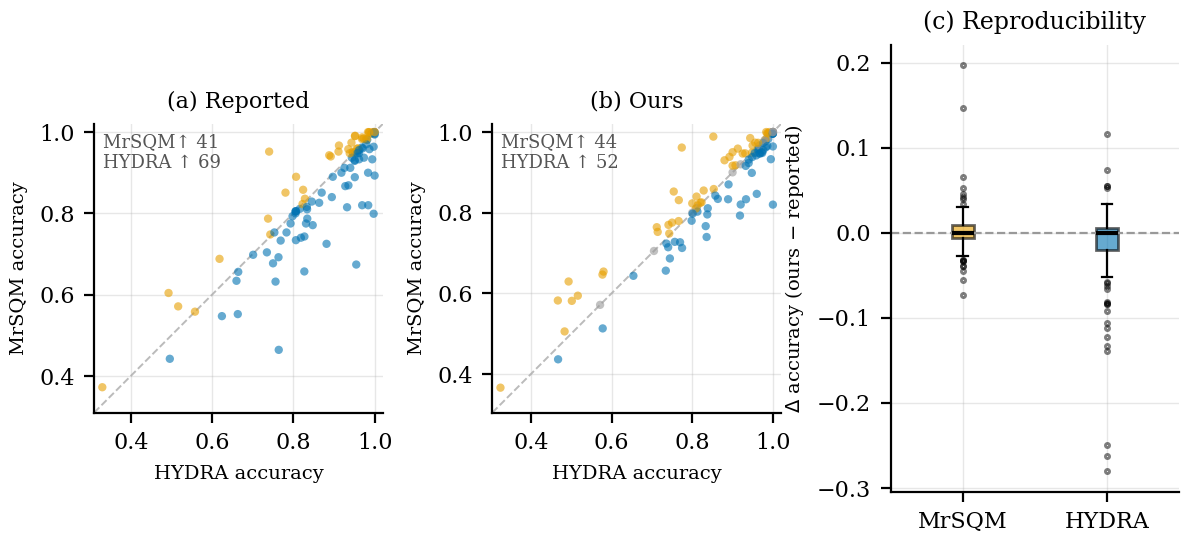

[plot_combined_figure] Saved -> figures/combined_analysis.png


'figures/combined_analysis.png'

In [16]:
plot_combined_figure(df)

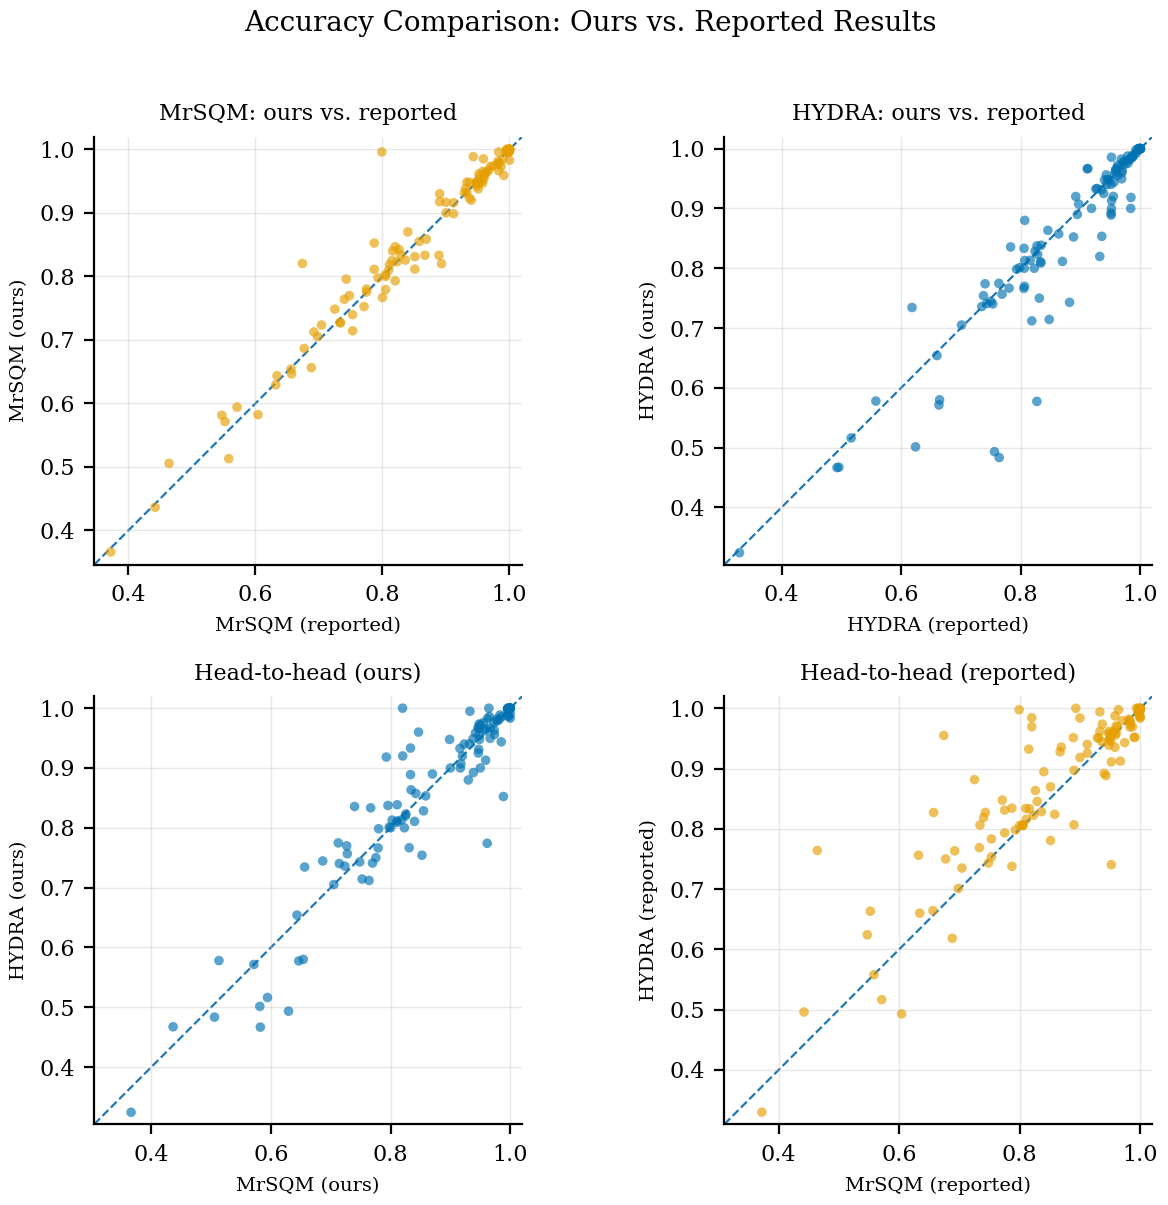


[plot_scatter_my_vs_reported] Saved -> figures/scatter_my_vs_reported.png


'figures/scatter_my_vs_reported.png'

In [17]:
plot_scatter_my_vs_reported(df)

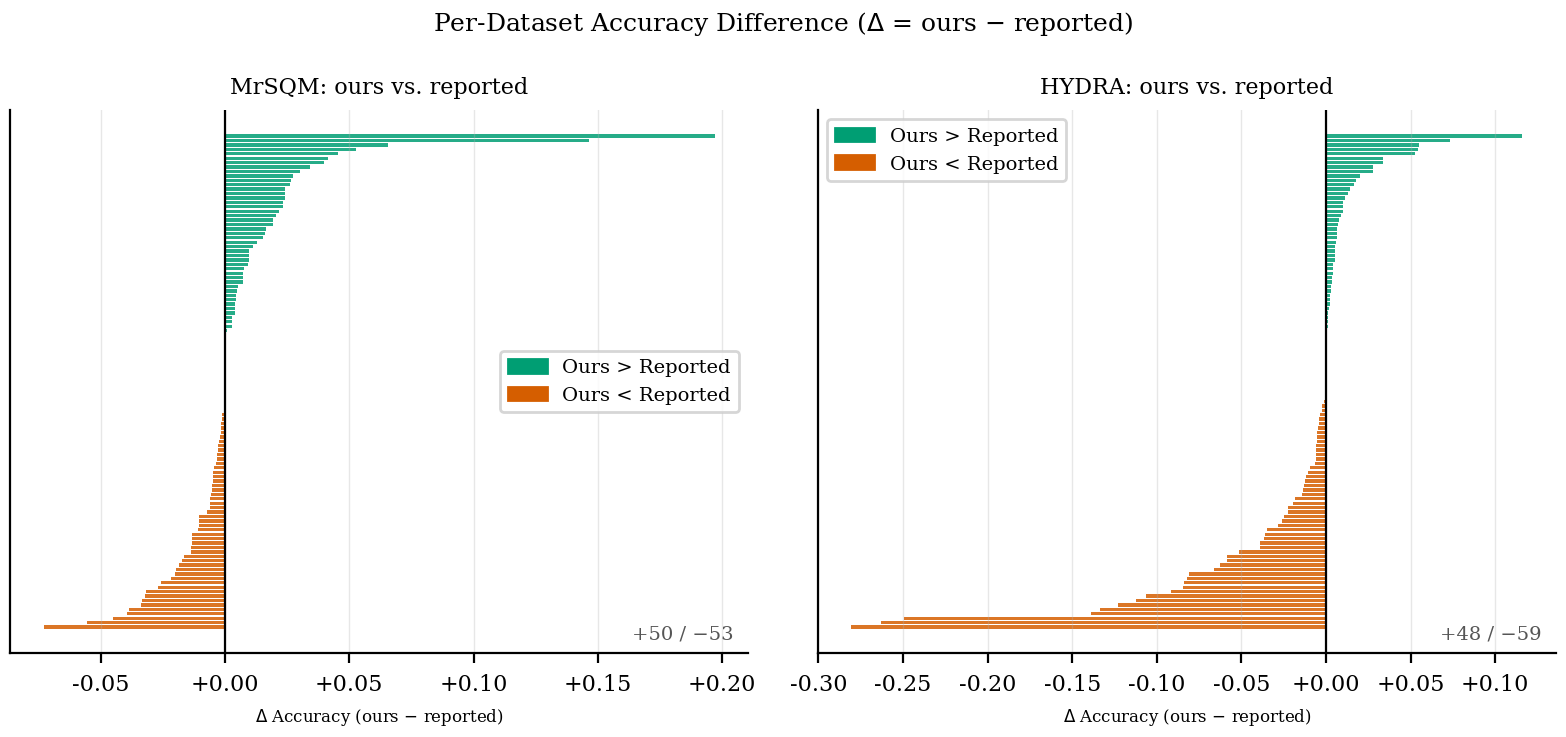

[plot_diff_bars] Saved -> figures/diff_bars.png


'figures/diff_bars.png'

In [18]:
plot_diff_bars(df)

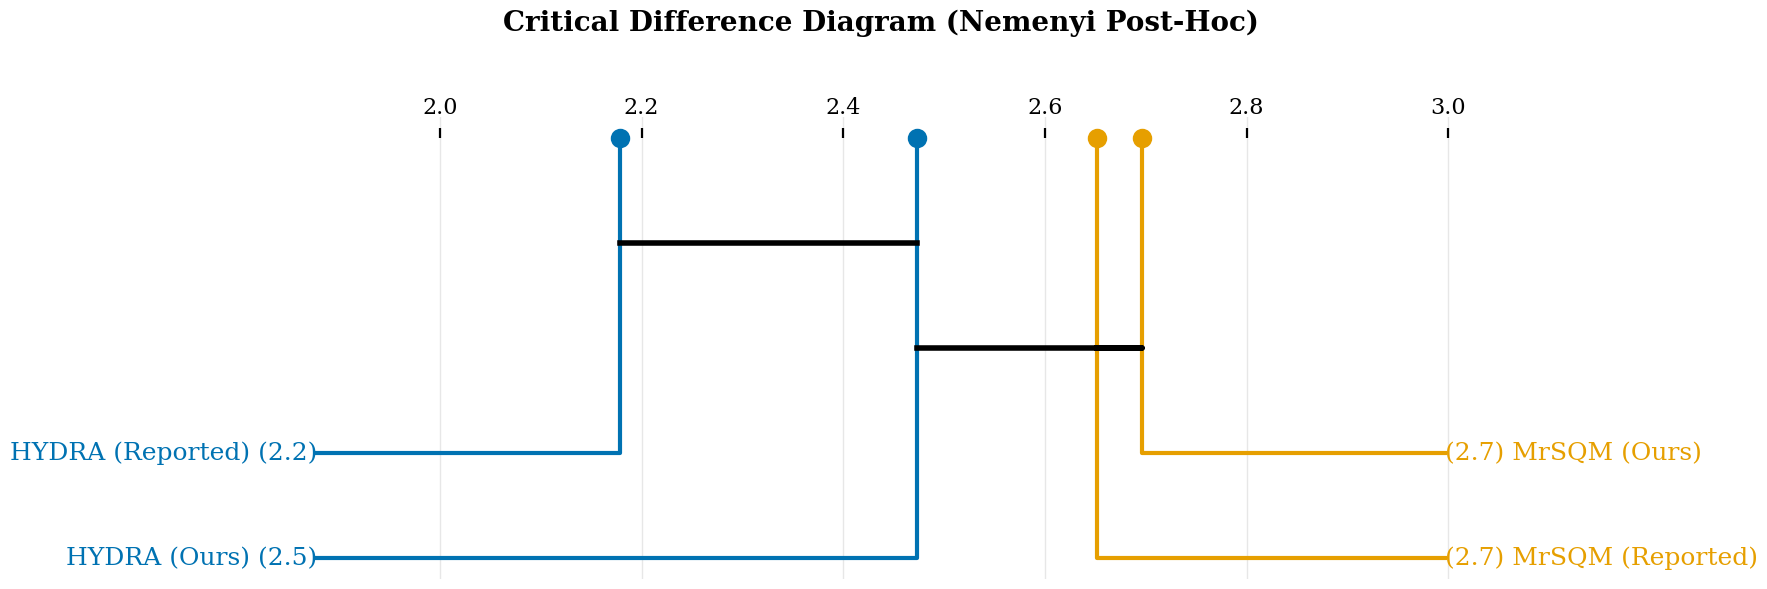

[plot_critical_difference] Saved -> figures/critical_difference.png


'figures/critical_difference.png'

In [19]:
_plot_critical_difference(df)